# Experiment 2 — learning curves (PD)

How AUC scales with training-set size (no HPO; the four leading methods). Pooled curves in four views, then per-dataset raw points, a data-efficiency table, and a summary of the **AUC trajectory** across the whole sweep. Figures → `figures/experiment2/pd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, imbalance_curve, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/pd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2\pd


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='pd', aggregated=False)
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 9 datasets, 1197 sweep points


## 1. AUC vs training-set size — pooled over datasets

Four views of the same curve (one line per method, mean over datasets):
1. **raw points**, 2. **moving average** (trend), 3. **relative to each method's own best**, 4. the **moving average of that relative** curve.

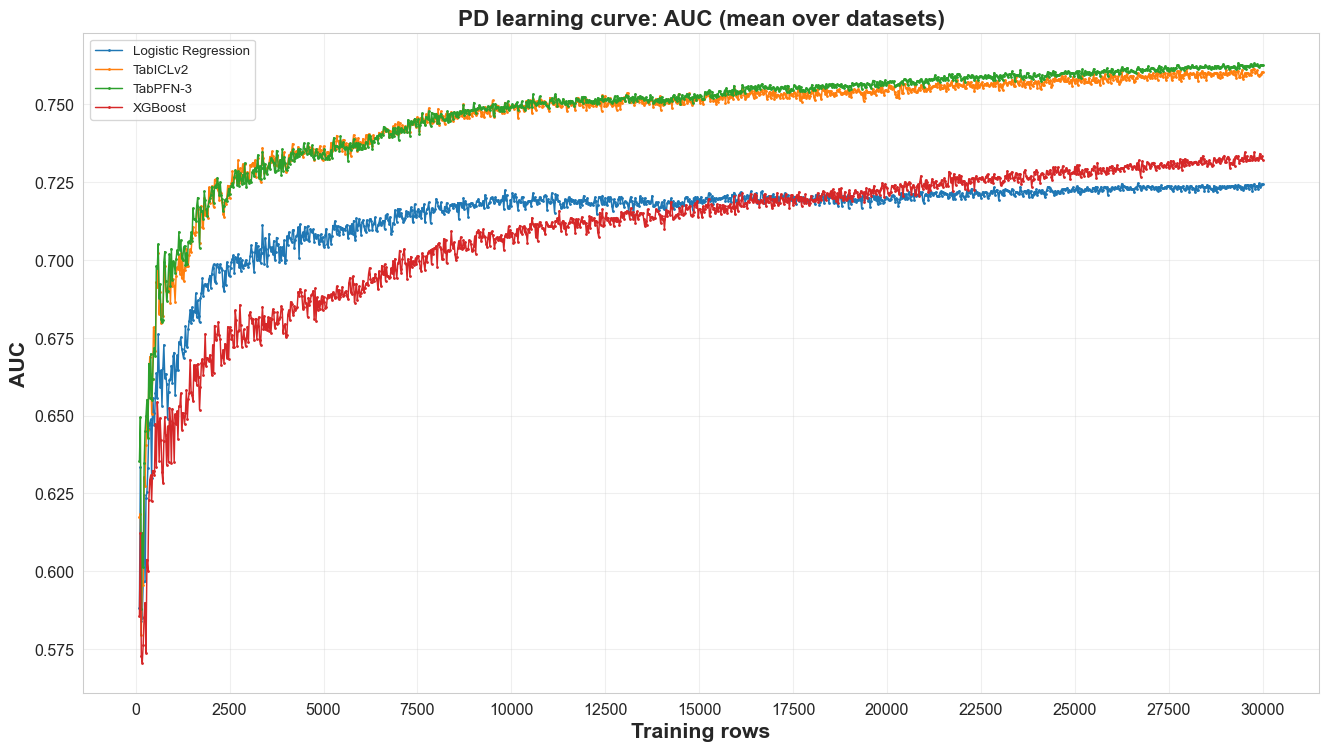

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc.pdf')

In [3]:
learning_curve(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

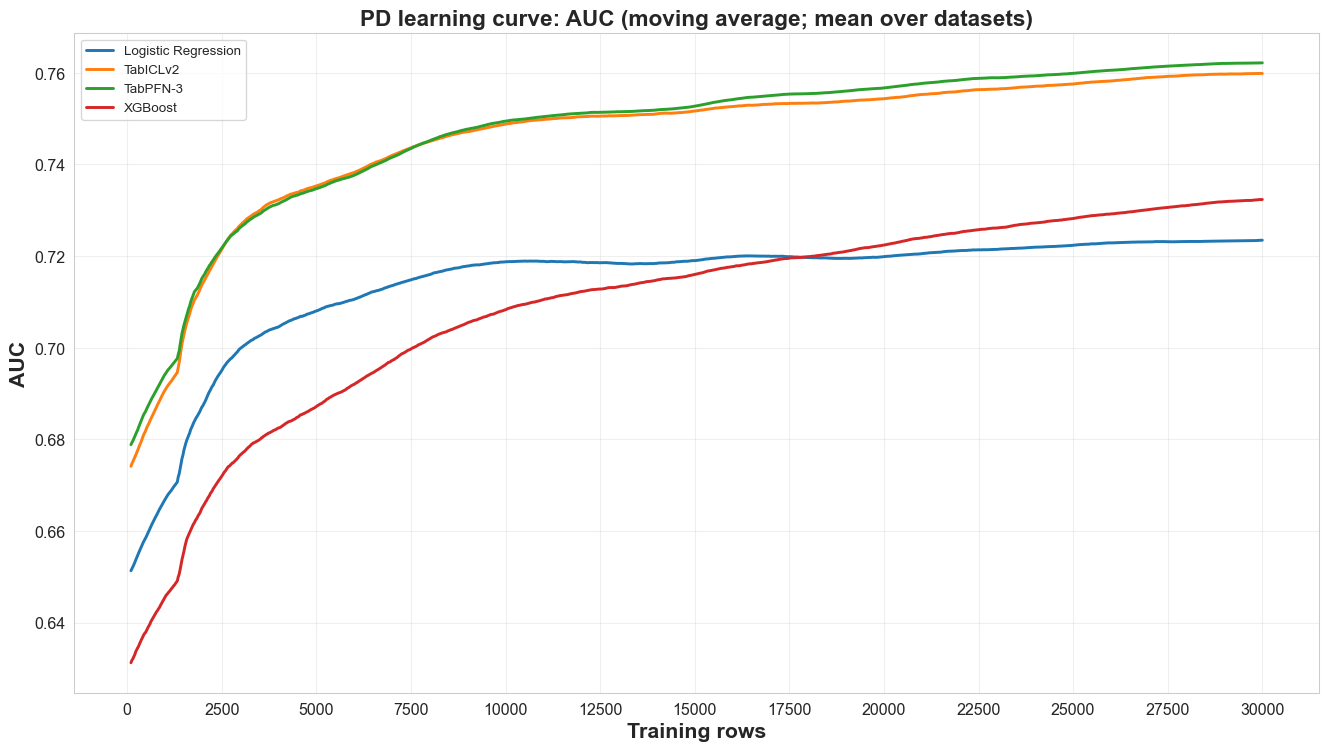

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc_smooth.pdf')

In [4]:
learning_curve(df, 'AUC', task_name='PD', smooth=True, out_dir=FIGURES_DIR)

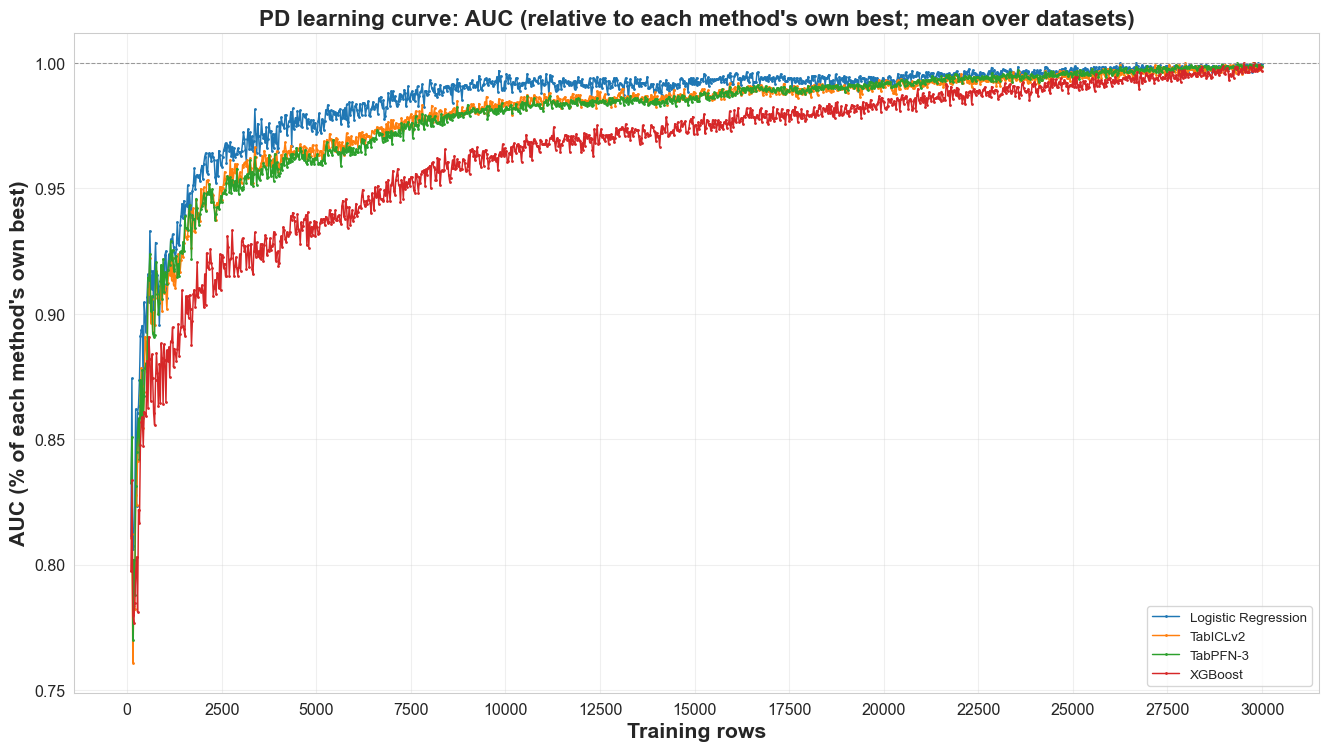

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc_relative.pdf')

In [5]:
learning_curve(df, 'AUC', task_name='PD', relative=True, out_dir=FIGURES_DIR)

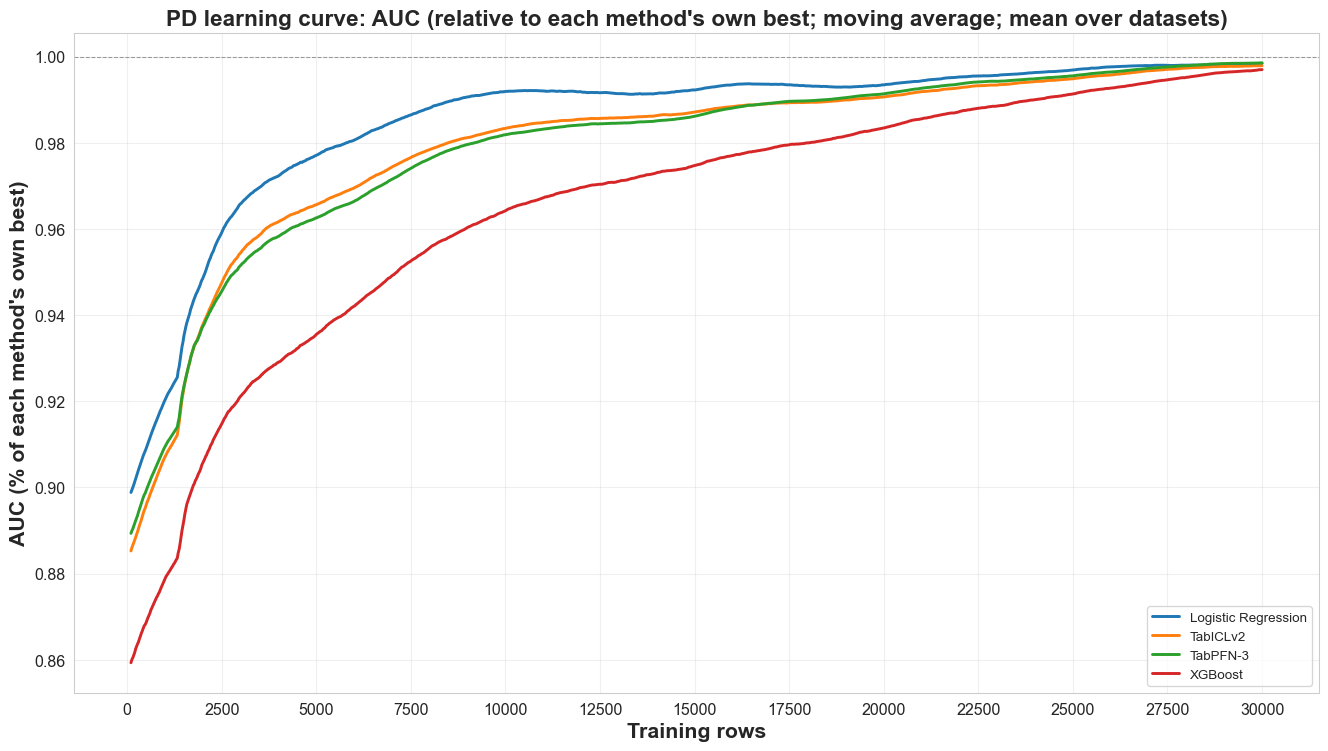

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc_relative_smooth.pdf')

In [6]:
learning_curve(df, 'AUC', task_name='PD', relative=True, smooth=True, out_dir=FIGURES_DIR)

## 2. AUC per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

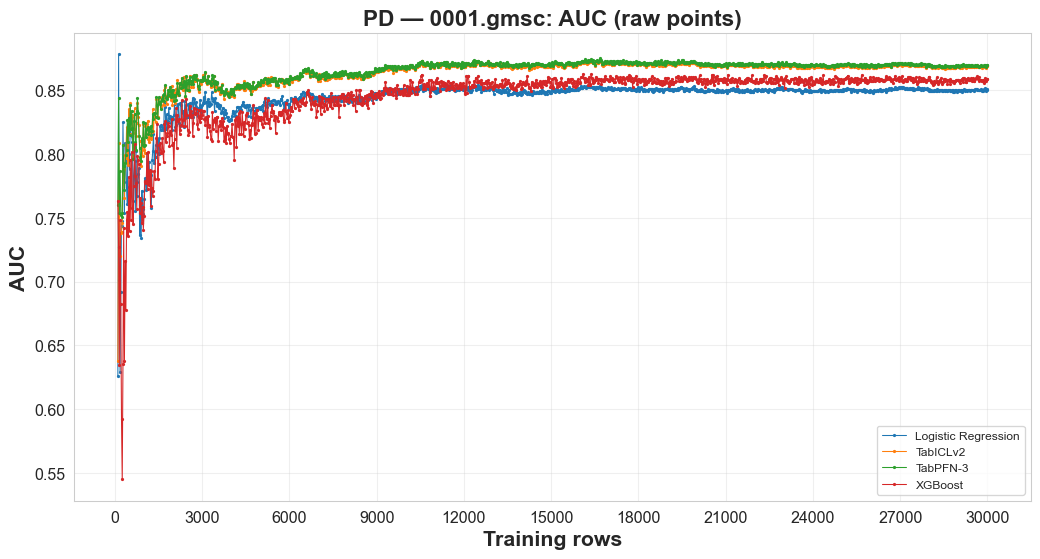

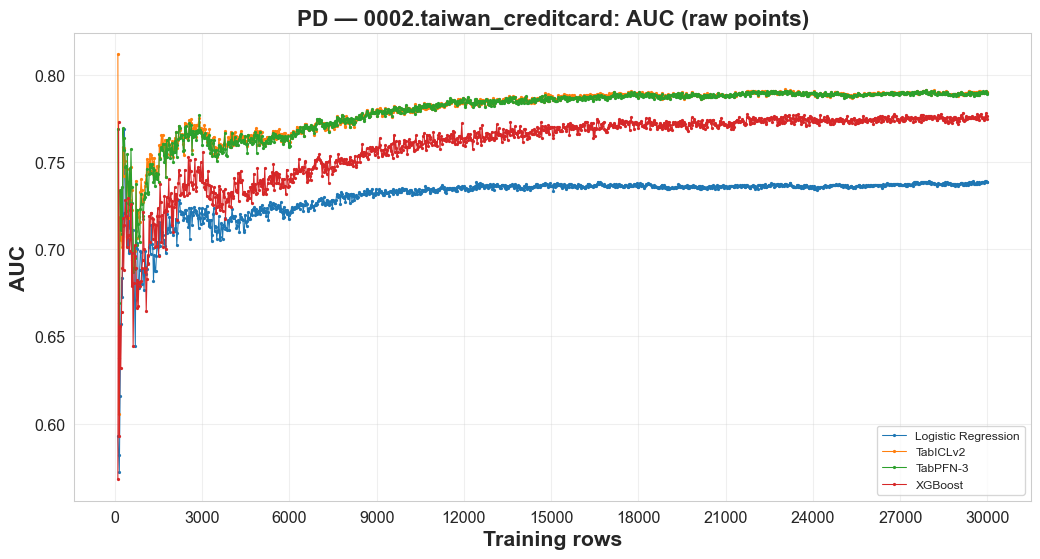

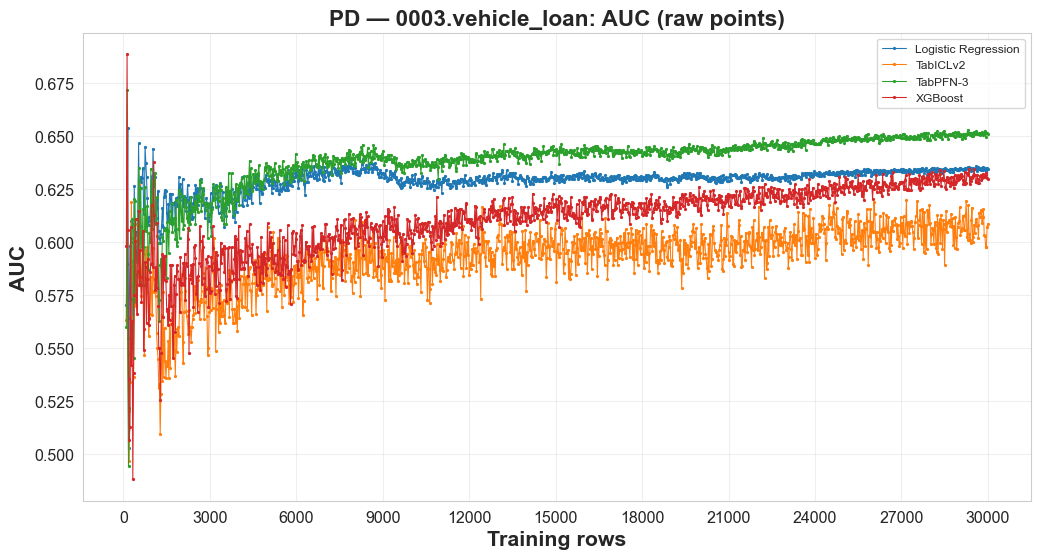

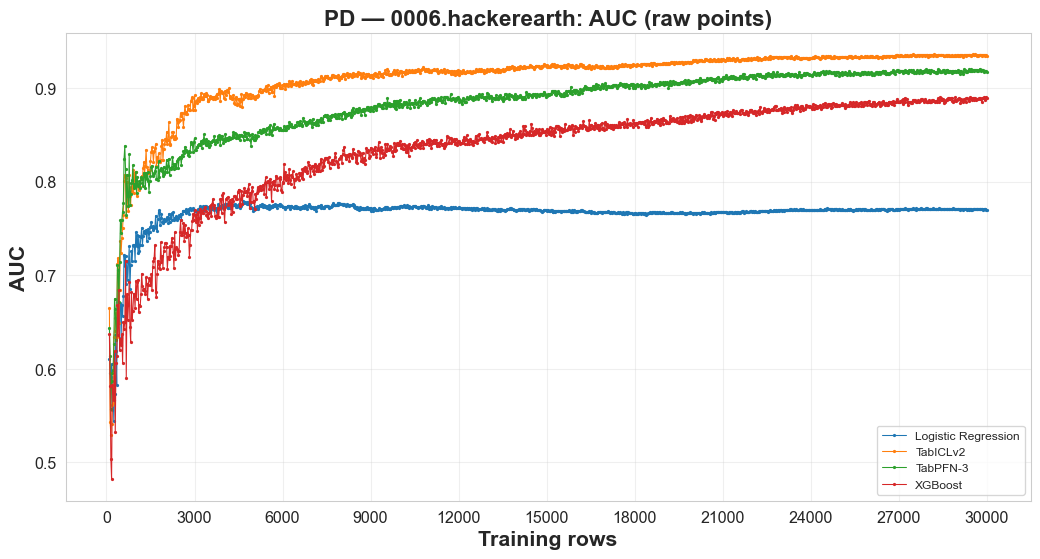

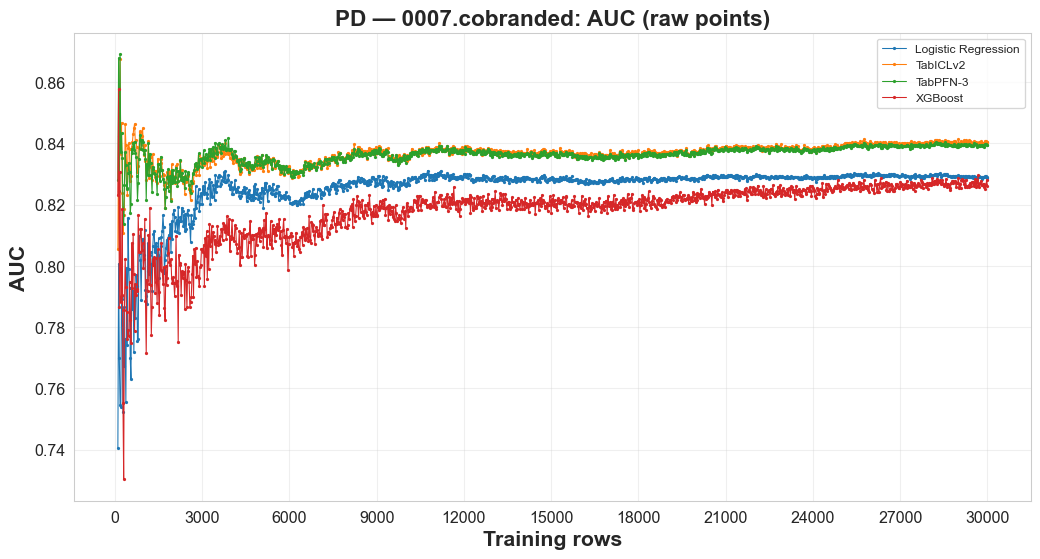

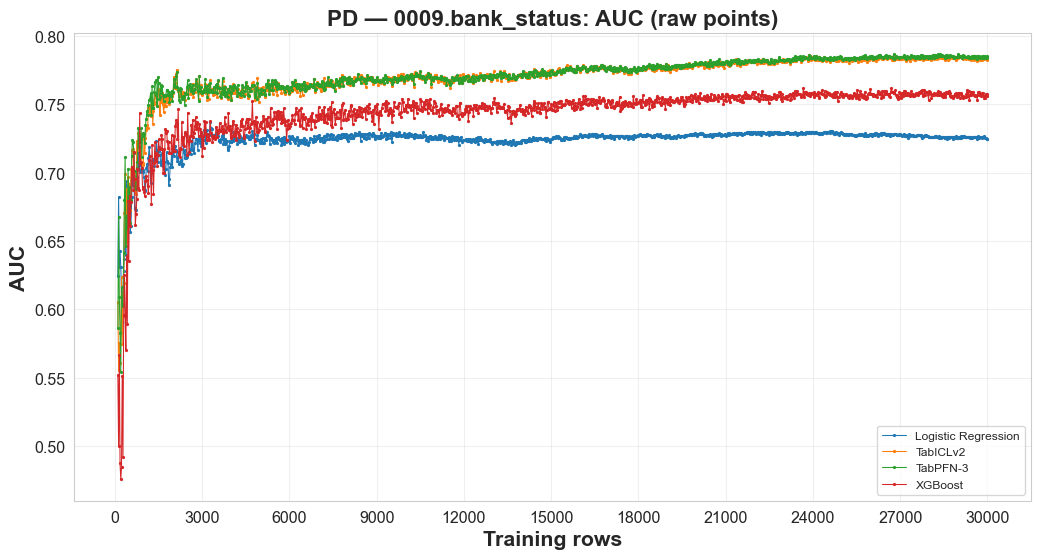

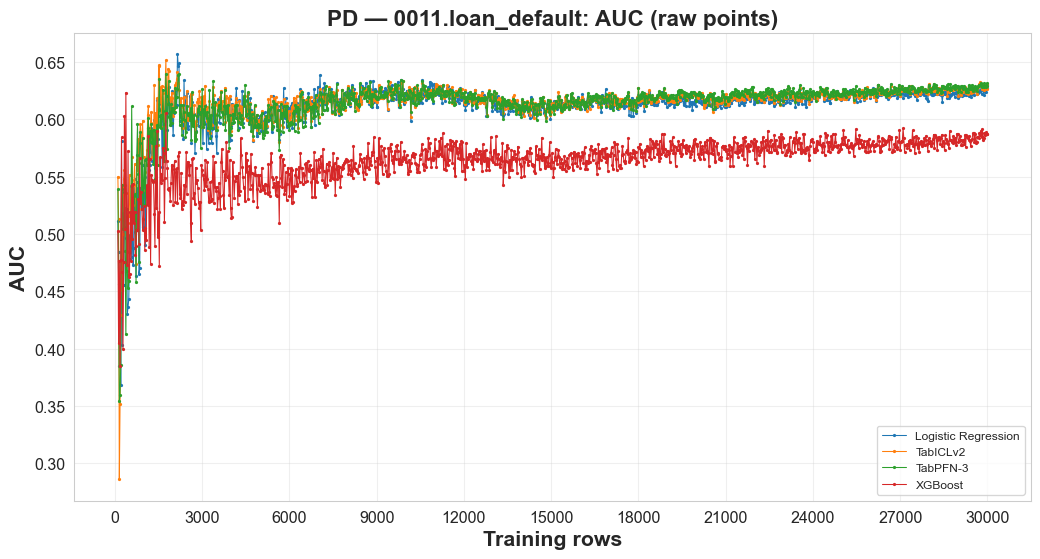

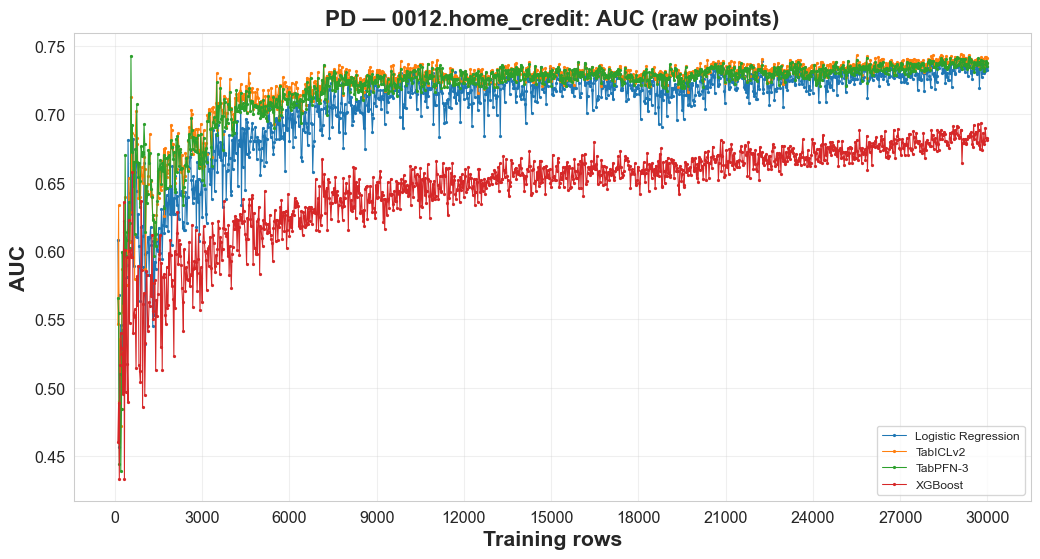

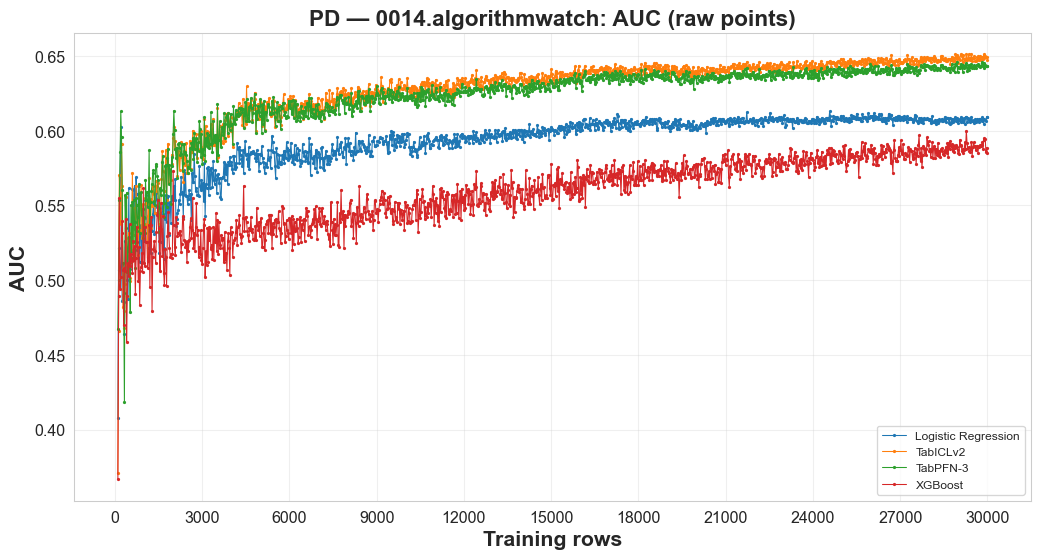

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0001_gmsc_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0002_taiwan_creditcard_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0003_vehicle_loan_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0006_hackerearth_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0007_cobranded_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0009_bank_status_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0011_loan_default_auc.pdf'),
 Window

In [7]:
per_dataset_sweep_curves(df, 'AUC', sweep_axis='row_limit', xlabel='Training rows', task_name='PD', out_dir=FIGURES_DIR)

## 3. Data efficiency — training rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.AUC'].max() * 0.95
    hit = gg[gg['metric.AUC'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='rows to reach 95% of own max AUC').sort_values())

LogReg       1600
tabicl_v2    2025
tabpfn_v3    2175
xgboost      6550
Name: rows to reach 95% of own max AUC, dtype: int64

## 4. Summary — AUC evolution over training-set size

Mean AUC per method across all datasets at a spread of training-set sizes (not just the largest), so the whole trajectory is visible.

In [9]:
sweep_evolution_summary(df, 'AUC', sweep_axis='row_limit',
                        task_name='Experiment 2 — PD', log_spacing=True, n_points=18)

Experiment 2 — PD — AUC evolution over row_limit  (mean across 9 datasets; 18 of 1197 sweep points; best average first)
sweep_value   100     150     200     275     375     525     750     1050    1475    2050    2875    4000    5600    7850    10975   15325   21450   30000
method                                                                                                                                                     
tabpfn_v3    0.6355  0.5878  0.6013  0.6500  0.6556  0.6691  0.6995  0.6959  0.7088  0.7221  0.7246  0.7291  0.7363  0.7430  0.7495  0.7523  0.7583  0.7625
tabicl_v2    0.6173  0.5794  0.5956  0.6406  0.6689  0.6707  0.6934  0.6866  0.7025  0.7187  0.7279  0.7283  0.7375  0.7442  0.7489  0.7523  0.7551  0.7603
LogReg       0.5880  0.5841  0.5967  0.6233  0.6475  0.6571  0.6727  0.6566  0.6797  0.6975  0.6982  0.7000  0.7108  0.7117  0.7196  0.7193  0.7207  0.7242
xgboost      0.5857  0.5728  0.5763  0.5738  0.6293  0.6473  0.6417  0.6504  0.6575  0.6727  0.6776 

"Experiment 2 — PD — AUC evolution over row_limit  (mean across 9 datasets; 18 of 1197 sweep points; best average first)\n======================================================================================================================\nsweep_value   100     150     200     275     375     525     750     1050    1475    2050    2875    4000    5600    7850    10975   15325   21450   30000\nmethod                                                                                                                                                     \ntabpfn_v3    0.6355  0.5878  0.6013  0.6500  0.6556  0.6691  0.6995  0.6959  0.7088  0.7221  0.7246  0.7291  0.7363  0.7430  0.7495  0.7523  0.7583  0.7625\ntabicl_v2    0.6173  0.5794  0.5956  0.6406  0.6689  0.6707  0.6934  0.6866  0.7025  0.7187  0.7279  0.7283  0.7375  0.7442  0.7489  0.7523  0.7551  0.7603\nLogReg       0.5880  0.5841  0.5967  0.6233  0.6475  0.6571  0.6727  0.6566  0.6797  0.6975  0.6982  0.7000  0.7108  0.7117  0.719